## Question 1: Piecewise Linear Intensity Transformation

### Methodology
In this task, a piecewise linear intensity transformation is implemented to alter the brightness and contrast of an image based on predefined breakpoints. The transformation function maps input pixel intensities to new output intensities using linear interpolation between the specified coordinate pairs $(x_i, y_i)$. 

To achieve this efficiently in Python using OpenCV, we compute a **Look-Up Table (LUT)** of size 256 (for 8-bit grayscale images). For every possible input pixel intensity $x \in [0, 255]$, we determine which segment $[x_i, x_{i+1}]$ it falls into and calculate the corresponding output $y$ using the linear equation:

$$y = m \cdot x + c$$

where the slope $m = \frac{y_{i+1} - y_i}{x_{i+1} - x_i}$ and the intercept $c = y_i - m \cdot x_i$. The calculated values are clipped to the $[0, 255]$ range and stored in the LUT. Finally, `cv2.LUT()` is used to quickly map all pixels in the input image to their new values.

### Implementation and Experiments
1. **Given Breakpoints:** The initial breakpoints `[[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]` apply a transformation that leaves the darkest shadows ($0-50$) untouched but increases the contrast and brightness for the mid-tones and highlights, pushing the input intensity of $150$ to a maximum white of $255$. This leads to a brighter overall image.
2. **Custom Breakpoints (Visually Pleasing):** To experiment with a visually pleasing output, we can define custom breakpoints like `[[0, 0], [70, 30], [180, 220], [255, 255]]`. This specific curve forms a subtle "S-curve". It slightly compresses the shadows (making dark areas richer), steepens the slope in the mid-tones (increasing overall contrast), and compresses the highlights to prevent clipping, often resulting in a more dramatic and aesthetically pleasing portrait.


Results using the breakpoints provided in the question:


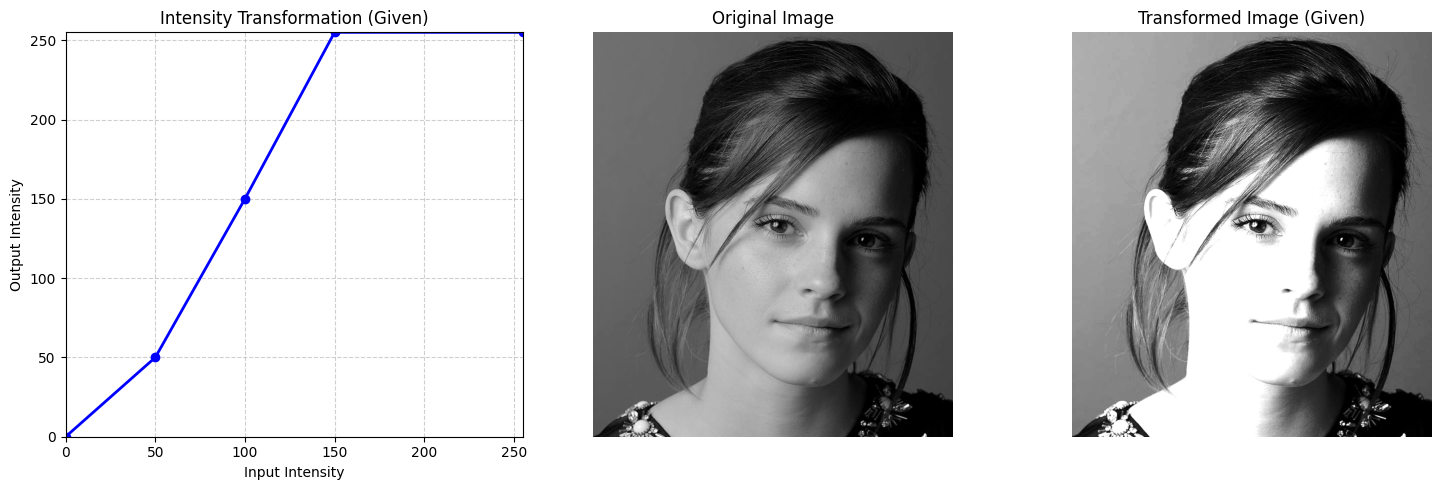

Results using custom breakpoints for a visually pleasing output:


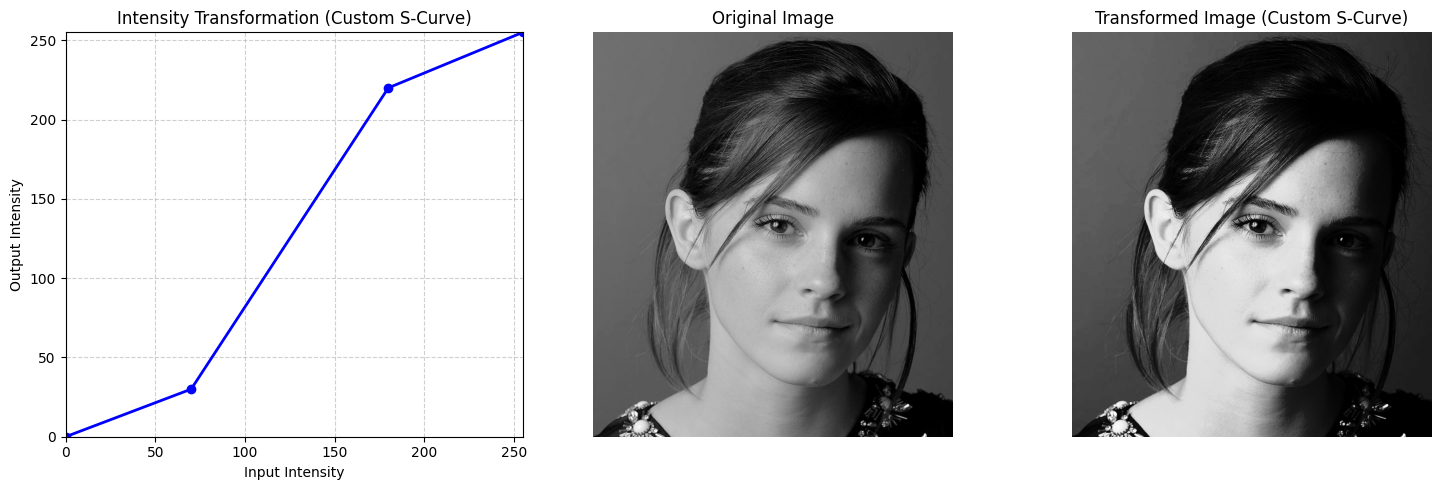

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    
    lut = np.zeros(256, dtype=np.uint8)
    
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i+1]
        
        if x2 - x1 != 0:
            m = (y2 - y1) / (x2 - x1)
        else:
            m = 0
            
        c = y1 - m * x1
        
        for x in range(x1, x2 + 1):
            if x < 256:
                val = m * x + c
                lut[x] = np.clip(val, 0, 255)
                
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im
img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q1.jpeg'

original_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


breakpoints_given = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed_image_given = intensity_transform(original_image, breakpoints_given)

def plot_results(original, transformed, breakpoints, title_suffix=""):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='blue', linewidth=2)
    plt.title(f'Intensity Transformation {title_suffix}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Transformed Image {title_suffix}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Results using the breakpoints provided in the question:")
plot_results(original_image, transformed_image_given, breakpoints_given, "(Given)")

breakpoints_custom = [
    [0, 0],
    [70, 30],   
    [180, 220],
    [255, 255]  
]

transformed_image_custom = intensity_transform(original_image, breakpoints_custom)

print("Results using custom breakpoints for a visually pleasing output:")
plot_results(original_image, transformed_image_custom, breakpoints_custom, "(Custom S-Curve)")


## Question 2: Accentuation of Specific Tissues

### Methodology
To accentuate specific regions in a medical image, such as white matter or gray matter in a brain proton density scan, we can use a piecewise linear intensity transformation called **contrast stretching** or **intensity windowing**. 

The goal is to increase the contrast for a specific, narrow range of input intensities corresponding to the tissue of interest. We achieve this by assigning a steep slope to that intensity range in our transformation curve. This maps a small range of input pixel values to a much wider range of output pixel values, making the subtle details within that tissue highly visible. Conversely, the intensity ranges corresponding to other tissues and the background are compressed using a shallow slope, pushing them towards black or white to reduce their visual distraction.

1. **(a) Accentuate White Matter:** In typical brain proton density or T1 MRI scans, white matter appears brighter than gray matter. To accentuate it, we identify the higher intensity band corresponding to white matter and create breakpoints that aggressively stretch this band (e.g., steepening the curve between input intensities of ~150 to ~220).
2. **(b) Accentuate Gray Matter:** Gray matter generally occupies the mid-tone intensity range. To accentuate it, we steepen the transformation curve in the middle of the histogram (e.g., stretching input intensities from ~80 to ~140), while flattening the curve for the darker cerebrospinal fluid (CSF) and the brighter white matter.

*Note: The exact intensity values for gray and white matter vary depending on the specific image. Looking at the image histogram helps precisely locate these intensity bands.*


Accentuation of White Matter:


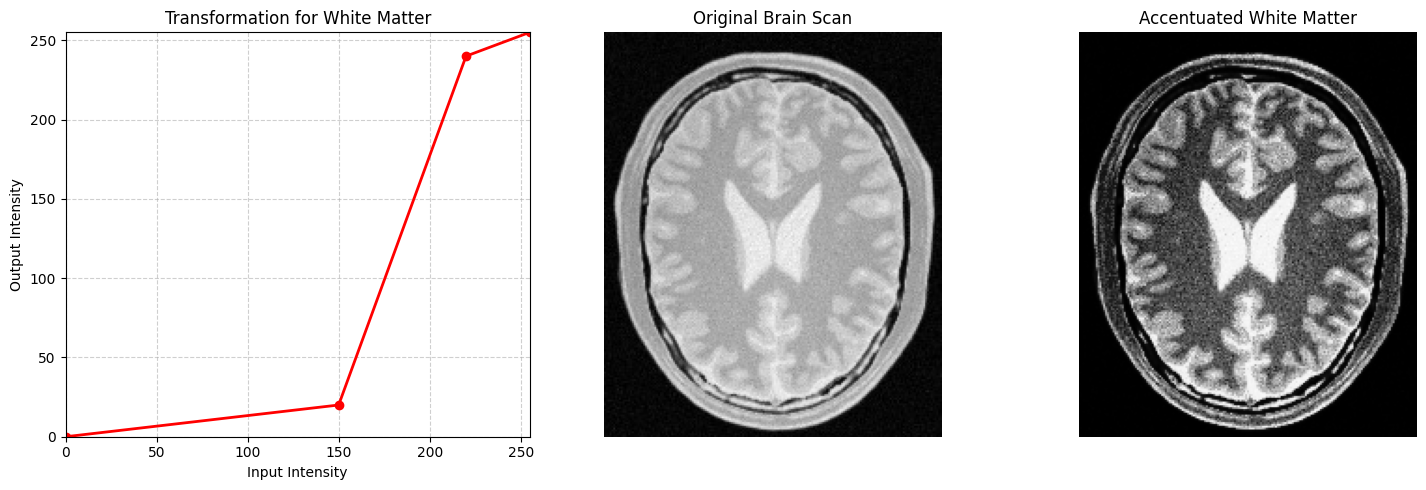

Accentuation of Gray Matter:


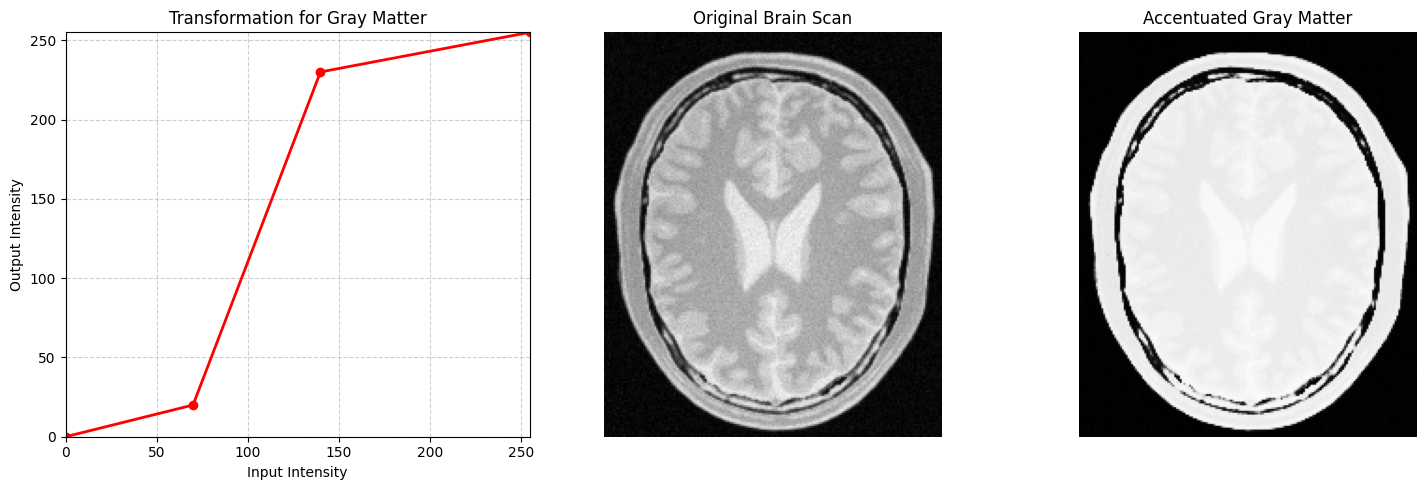

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q2.jpeg' 
brain_image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    
breakpoints_wm = [
    [0, 0],
    [150, 20],   
    [220, 240],  
    [255, 255]
]

accentuated_wm = intensity_transform(brain_image, breakpoints_wm)

breakpoints_gm = [
    [0, 0],
    [70, 20],    
    [140, 230],  
    [255, 255]   
]

accentuated_gm = intensity_transform(brain_image, breakpoints_gm)

def plot_accentuation(original, transformed, breakpoints, target_name):
    x_coords = [bp[0] for bp in breakpoints]
    y_coords = [bp[1] for bp in breakpoints]
    
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Intensity Transformation Curve
    plt.subplot(1, 3, 1)
    plt.plot(x_coords, y_coords, marker='o', color='red', linewidth=2)
    plt.title(f'Transformation for {target_name}')
    plt.xlabel('Input Intensity')
    plt.ylabel('Output Intensity')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim([0, 255])
    plt.ylim([0, 255])
    
    # Plot 2: Original Image
    plt.subplot(1, 3, 2)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title('Original Brain Scan')
    plt.axis('off')
    
    # Plot 3: Transformed Image
    plt.subplot(1, 3, 3)
    plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Accentuated {target_name}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Display results
print("Accentuation of White Matter:")
plot_accentuation(brain_image, accentuated_wm, breakpoints_wm, "White Matter")

print("Accentuation of Gray Matter:")
plot_accentuation(brain_image, accentuated_gm, breakpoints_gm, "Gray Matter")


## Question 3: Gamma Correction in L\*a\*b\* Color Space

### Methodology
In this task, we apply gamma correction to an image to adjust its overall brightness and contrast, specifically targeting the dark regions (like the rocks in Fig 3). 

1. **Why L\*a\*b\* Color Space?** If we apply intensity transformations directly to RGB channels, we risk altering the color balance (chromaticity) of the image, causing unnatural color shifts. By converting the image to the **CIE L\*a\*b\*** color space, we separate the Lightness (L) from the color information (a and b channels). We can safely manipulate the L plane to change brightness without affecting the actual colors in the image.
2. **Gamma Correction:** Gamma correction is a non-linear operation described by the power-law equation: 
   $$V_{out} = c \cdot V_{in}^{\gamma}$$
   For an 8-bit image, the pixel values are normalized to $[0, 1]$, raised to the power of $\gamma$, and then scaled back to $[0, 255]$. 
   * A **$\gamma < 1$** expands the dark regions (increasing their contrast and brightness) while compressing the bright regions. This is ideal for revealing details hidden in shadows.
   * A **$\gamma > 1$** does the opposite, darkening the image.

### Results
* **Gamma Value:** I applied a gamma value of **$\gamma = 0.5$**. This value was chosen because it significantly brightens the dark, underexposed rocks in the background, revealing texture and detail, without completely washing out the bright white dress.
* **Histograms:** The histograms clearly illustrate the effect. The histogram of the original Lightness (L) plane has a heavy concentration of pixels clustered near the left side (dark values). After applying the $\gamma = 0.5$ correction, the histogram is "stretched" and shifted towards the right (mid-tones and highlights), demonstrating that the shadow regions have been successfully brightened.


<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\181906269.py:32: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.title(f'Gamma Corrected ($\gamma$ = {gamma})')


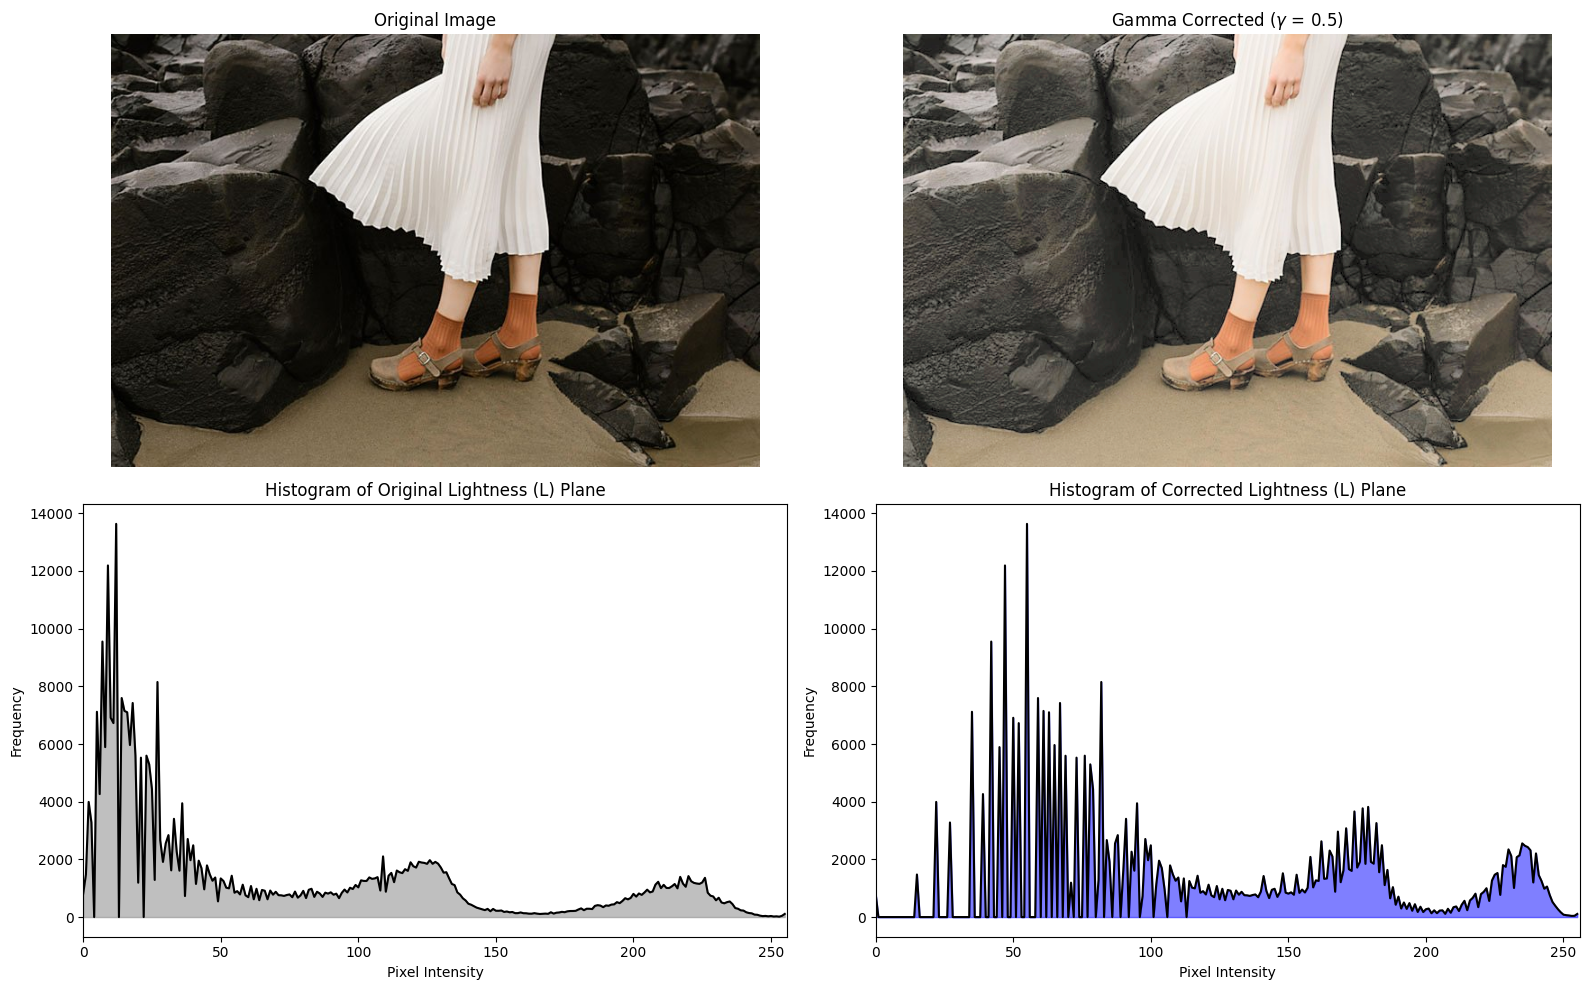

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path = r'D:\VISION\VISION-ASSIGNEMNT\images\q3.jpeg' 
img_bgr = cv2.imread(img_path)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(img_lab)

gamma = 0.5 

lut = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

L_corrected = cv2.LUT(L, lut)

img_lab_corrected = cv2.merge((L_corrected, a, b))
img_bgr_corrected = cv2.cvtColor(img_lab_corrected, cv2.COLOR_LAB2BGR)
img_rgb_corrected = cv2.cvtColor(img_bgr_corrected, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_rgb_corrected)
plt.title(f'Gamma Corrected ($\gamma$ = {gamma})')
plt.axis('off')

plt.subplot(2, 2, 3)
hist_original = cv2.calcHist([L], [0], None, [256], [0, 256])
plt.plot(hist_original, color='black')
plt.fill_between(range(256), hist_original.flatten(), color='gray', alpha=0.5)
plt.title('Histogram of Original Lightness (L) Plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
hist_corrected = cv2.calcHist([L_corrected], [0], None, [256], [0, 256])
plt.plot(hist_corrected, color='black')
plt.fill_between(range(256), hist_corrected.flatten(), color='blue', alpha=0.5)
plt.title('Histogram of Corrected Lightness (L) Plane')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()


## Question 4: Increasing Vibrance via Intensity Transformation

### Methodology
In this task, we aim to increase the "vibrance" of a photograph. Unlike a simple global saturation boost which might oversaturate already colorful areas, vibrance selectively enhances muted colors while protecting already well-saturated colors.

1. **Why HSV Color Space?** To manipulate color intensity without altering the hue (the actual color) or the value (the brightness), we convert the image from RGB to the **HSV (Hue, Saturation, Value)** color space. By isolating the Saturation (S) plane, we can specifically target and adjust how vivid the colors appear without changing the underlying image structure.
2. **Intensity Transformation:** We apply a non-linear transformation specifically to the saturation plane:
   $$f(x) = \min\left(x + a \times 128e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$$
   where $x$ is the input saturation, $a \in [0, 1]$ controls the strength of the enhancement, and $\sigma = 70$.
   * This function utilizes a Gaussian curve centered at an intensity of 128. It adds the most saturation to mid-tone saturation values while having significantly less effect on very low (near grayscale) and very high (already saturated) values. This prevents the clipping and unnatural oversaturation that a linear boost would cause. The $\min(\dots, 255)$ operation ensures the final values remain within the valid 8-bit range.

### Results
* **Parameter Value:** Through experimentation, I adjusted the parameter and found that **$a = 0.5$** yields a visually pleasing, balanced output. 
* **Visual Effect:** By applying this transformation to the S plane and recombining it with the original H and V planes, the colors in the resulting image appear noticeably more vivid and punchy. The intensity transformation plot confirms that mid-range saturation values receive the largest boost, successfully enhancing the image's overall vibrance while preserving natural tones.


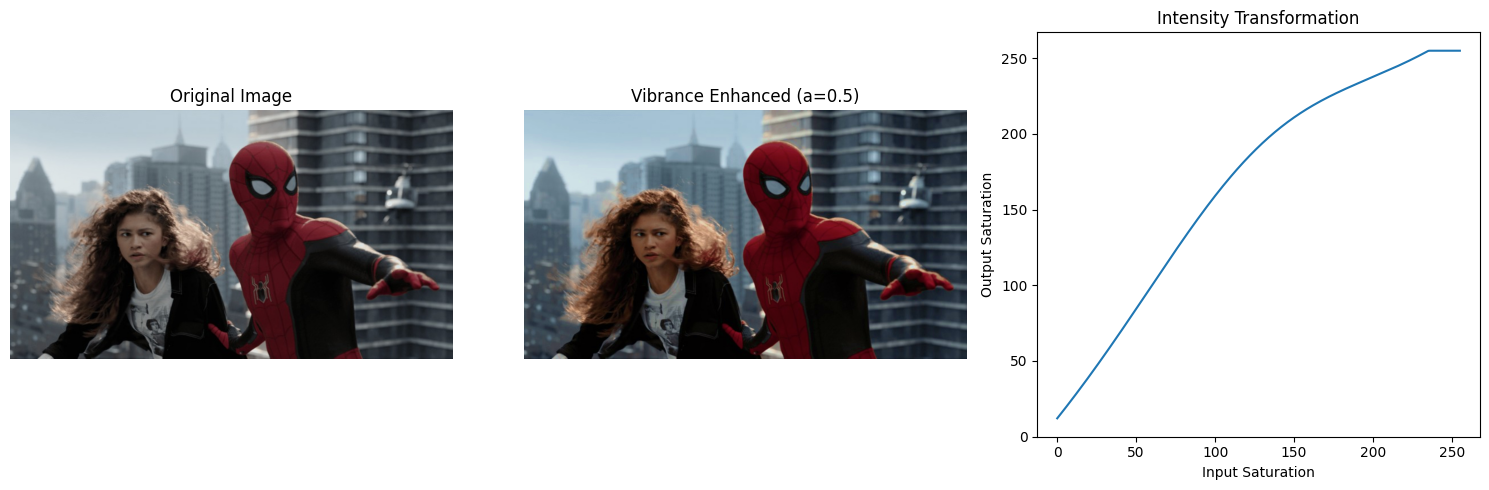

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/q4.jpeg') # Update filename if necessary
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

a = 0.5 
sigma = 70

s_float = s.astype(np.float32)
s_transformed = s_float + a * 128 * np.exp(-((s_float - 128)**2) / (2 * sigma**2))
s_transformed = np.clip(s_transformed, 0, 255).astype(np.uint8)

img_hsv_transformed = cv2.merge([h, s_transformed, v])
img_vibrance = cv2.cvtColor(img_hsv_transformed, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(img_vibrance)
axes[1].set_title(f'Vibrance Enhanced (a={a})')
axes[1].axis('off')

x = np.arange(0, 256)
y = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255)
axes[2].plot(x, y)
axes[2].set_title('Intensity Transformation')
axes[2].set_xlabel('Input Saturation')
axes[2].set_ylabel('Output Saturation')

plt.tight_layout()
plt.show()


## Question 5: Custom Histogram Equalization

### Methodology
In this task, we implement a custom function to perform histogram equalization from scratch. Histogram equalization is a spatial domain technique used to improve the global contrast of an image by redistributing its pixel intensities.

1. **Computing the Histogram:** The first step is to calculate the histogram of the grayscale image, which simply counts the frequency of occurrence for each possible pixel intensity value (from 0 to 255).
2. **Cumulative Distribution Function (CDF):** Next, we compute the cumulative sum of the histogram to obtain the Cumulative Distribution Function (CDF). The CDF serves as the basis for our transformation function, mapping original pixel intensities to their new, equalized values.
3. **Normalization and Mapping:** To ensure the output image utilizes the full 8-bit dynamic range, we normalize the CDF. We scale it such that its minimum non-zero value maps to 0 and its maximum value maps to 255. Finally, we use this normalized CDF as a lookup table, replacing every original pixel intensity in the image with its corresponding equalized value.

### Results
* **Contrast Improvement:** By applying our custom histogram equalization function, the contrast of the original image is significantly enhanced. The image utilizes a wider range of intensities, making details and textures that were previously muddy or hidden in low-contrast areas much more pronounced and visible.
* **Histograms:** The histograms clearly demonstrate the mathematical effect of the equalization. The histogram of the original image shows a tight clustering of pixel intensities within a narrow range. After equalization, the histogram is effectively "stretched" out. While not perfectly flat, the pixel intensities are distributed much more broadly and evenly across the entire 0-255 range, confirming a successful contrast enhancement.


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\2271081882.py:28: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0, 1].hist(img.flatten(), 256, [0, 256], color='black')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_34012\2271081882.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(img_eq.flatten(), 256, [0, 256], color='black')


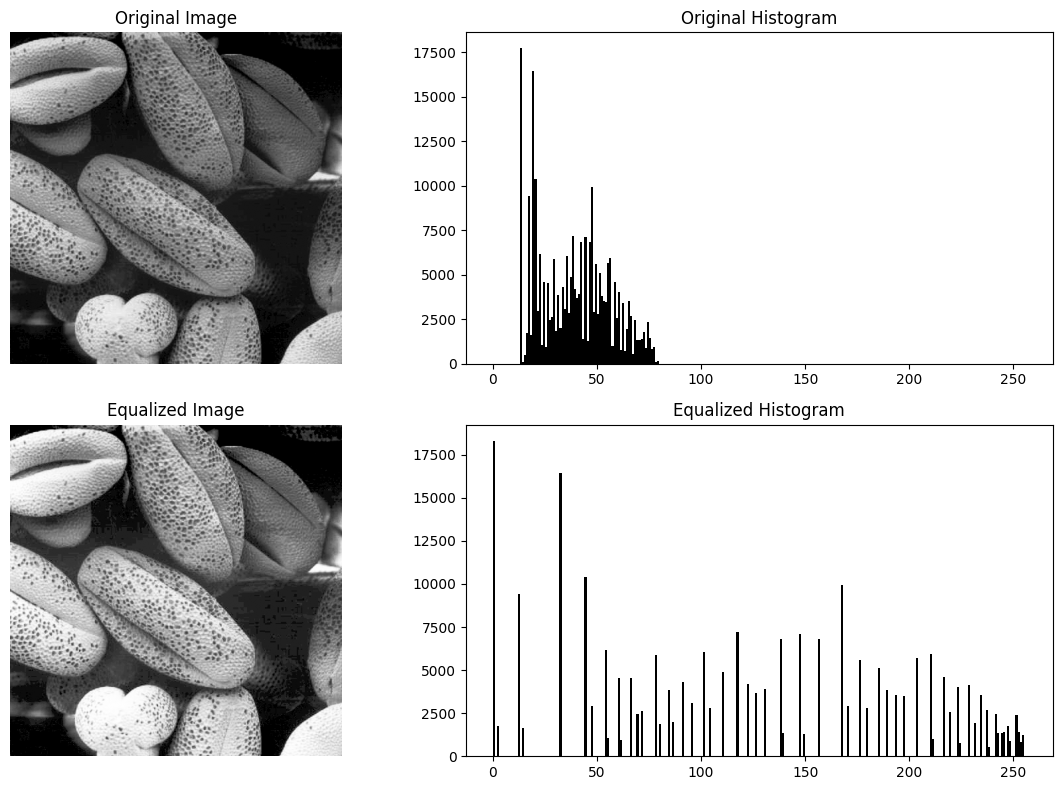

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def custom_histogram_equalize(image):
    hist, _ = np.histogram(image.flatten(), 256, [0, 256])
    
    cdf = hist.cumsum()
    
    cdf_masked = np.ma.masked_equal(cdf, 0)
    cdf_masked = (cdf_masked - cdf_masked.min()) * 255 / (cdf_masked.max() - cdf_masked.min())
    cdf_final = np.ma.filled(cdf_masked, 0).astype('uint8')
    
    img_equalized = cdf_final[image]
    return img_equalized

img = cv2.imread('images/q5.tif', cv2.IMREAD_GRAYSCALE)


img_eq = custom_histogram_equalize(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].hist(img.flatten(), 256, [0, 256], color='black')
axes[0, 1].set_title('Original Histogram')

axes[1, 0].imshow(img_eq, cmap='gray')
axes[1, 0].set_title('Equalized Image')
axes[1, 0].axis('off')

axes[1, 1].hist(img_eq.flatten(), 256, [0, 256], color='black')
axes[1, 1].set_title('Equalized Histogram')

plt.tight_layout()
plt.show()


## Question 6: Foreground-Only Histogram Equalization

### Methodology
In this task, we perform histogram equalization exclusively on the foreground of an image, leaving the background untouched. 

1. **Color Space Conversion and Splitting:** We convert the original RGB image to the HSV (Hue, Saturation, Value) color space and split it into its individual H, S, and V planes.
2. **Foreground Mask Extraction:** To isolate the foreground, we threshold the Saturation (S) plane. Since the background is gray (low saturation) and the subject has color (higher saturation), applying Otsu's thresholding to the S plane cleanly separates the foreground into a binary mask.
3. **Foreground Histogram and CDF:** Using `cv.bitwise_and` with the mask, we extract just the foreground of the V plane and calculate its histogram. We then compute the Cumulative Distribution Function (CDF) for this foreground histogram.
4. **Equalization and Recombination:** We normalize the CDF and use it to map the pixel values. We use bitwise operations to extract the new equalized foreground and the original un-equalized background, and add them together. Finally, we recombine the H, S, and new V planes and convert back to RGB.

### Results
* **Mask Extraction:** The Saturation plane proved to be highly effective for thresholding, cleanly separating the colored subject from the desaturated background.
* **Visual Effect:** By targeting only the foreground, we successfully enhanced the contrast and details of the subject without artificially blowing out or introducing noise into the flat background.


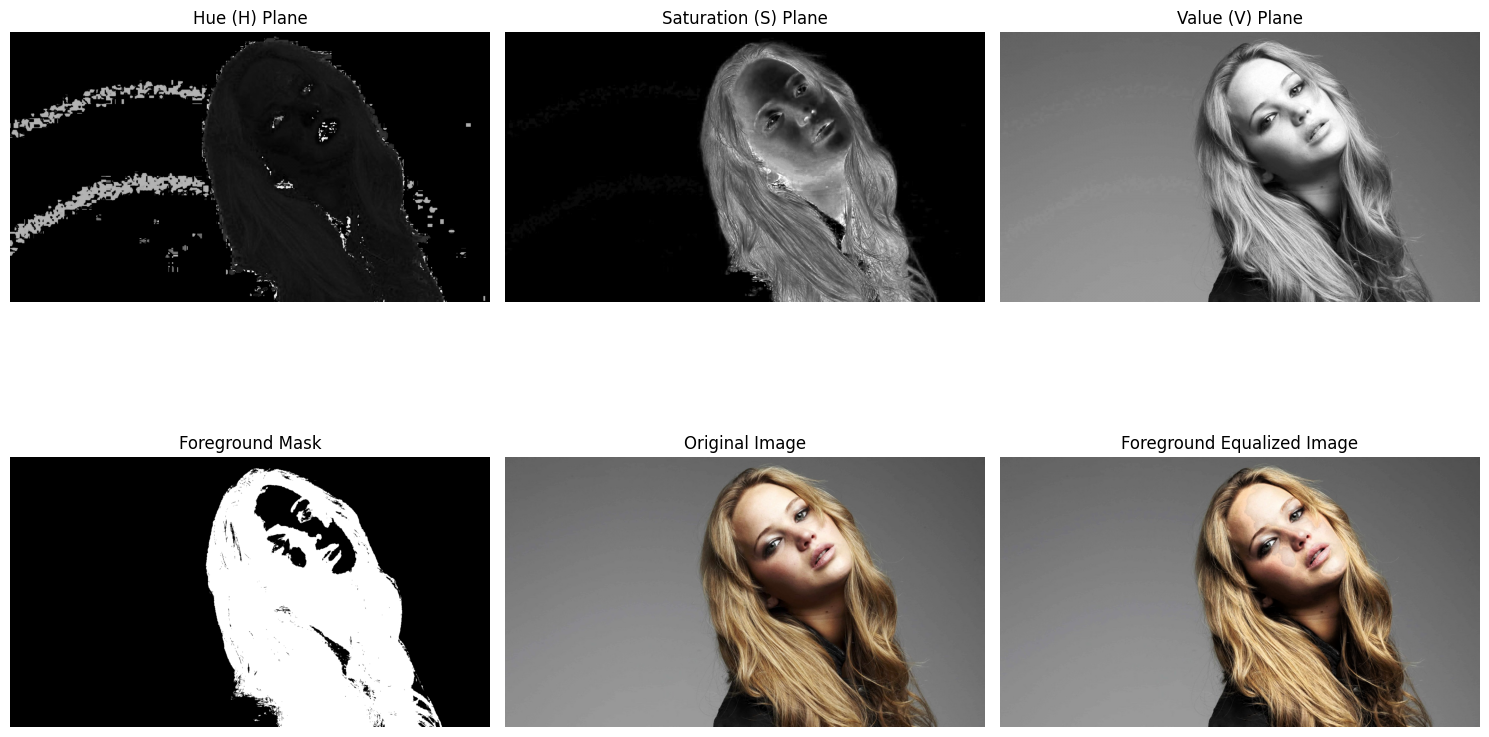

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('images/q6.jpeg') # Update filename if necessary
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# (a) Split into H, S, V planes
H, S, V = cv2.split(img_hsv)

# (b) Threshold the Saturation plane to extract foreground mask
_, mask = cv2.threshold(S, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# (c) Obtain foreground only and compute histogram
fg_only = cv2.bitwise_and(V, V, mask=mask)
hist = cv2.calcHist([fg_only], [0], mask, [256], [0, 256])

# (d) Obtain cumulative sum
cdf = hist.cumsum()

# (e) Histogram-equalize the foreground
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

V_eq_mapped = cdf_final[V]

# (f) Extract background and add with equalized foreground
eq_fg = cv2.bitwise_and(V_eq_mapped, V_eq_mapped, mask=mask)
mask_inv = cv2.bitwise_not(mask)
bg = cv2.bitwise_and(V, V, mask=mask_inv)

V_final = cv2.add(eq_fg, bg)

# Recombine and convert back to RGB
img_hsv_eq = cv2.merge([H, S, V_final])
img_rgb_eq = cv2.cvtColor(img_hsv_eq, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(H, cmap='gray')
axes[0, 0].set_title('Hue (H) Plane')
axes[0, 0].axis('off')

axes[0, 1].imshow(S, cmap='gray')
axes[0, 1].set_title('Saturation (S) Plane')
axes[0, 1].axis('off')

axes[0, 2].imshow(V, cmap='gray')
axes[0, 2].set_title('Value (V) Plane')
axes[0, 2].axis('off')

axes[1, 0].imshow(mask, cmap='gray')
axes[1, 0].set_title('Foreground Mask')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_rgb)
axes[1, 1].set_title('Original Image')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_rgb_eq)
axes[1, 2].set_title('Foreground Equalized Image')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
